### 1. 도면 시각화

In [1]:
# ============================================================
# [STEP 0] 한글 폰트 설정
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 기본 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

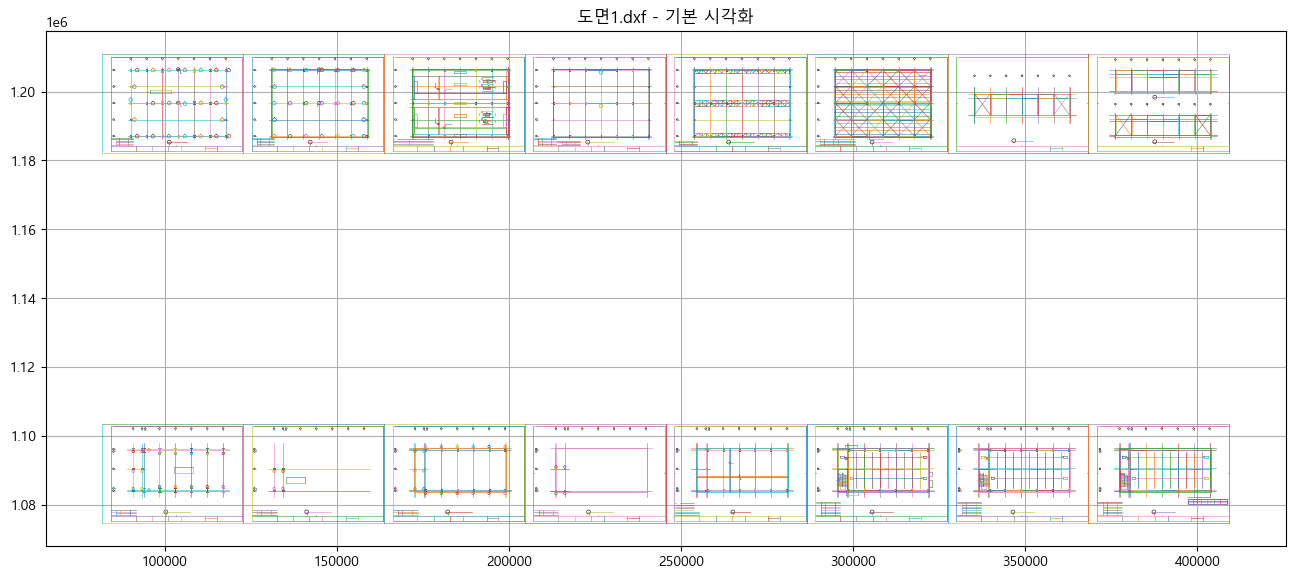

In [3]:
# ============================================================
# [STEP 1] DXF 도면1 시각화
# ============================================================

from pathlib import Path
import ezdxf
import matplotlib.pyplot as plt

dxf_path = Path(r"D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data_01\도면1.dxf")

doc = ezdxf.readfile(dxf_path)
msp = doc.modelspace()

fig, ax = plt.subplots(figsize=(16, 16))

for e in msp:
    etype = e.dxftype()

    # LINE
    if etype == "LINE":
        x1, y1, _ = e.dxf.start
        x2, y2, _ = e.dxf.end
        ax.plot([x1, x2], [y1, y2], linewidth=0.4)

    # LWPOLYLINE
    elif etype == "LWPOLYLINE":
        points = [(p[0], p[1]) for p in e.get_points()]
        if len(points) >= 2:
            xs, ys = zip(*points)

            if e.closed:
                xs = xs + (xs[0],)
                ys = ys + (ys[0],)

            ax.plot(xs, ys, linewidth=0.5)

    # CIRCLE
    elif etype == "CIRCLE":
        center = e.dxf.center
        radius = e.dxf.radius
        circle = plt.Circle((center.x, center.y), radius, fill=False, linewidth=0.4)
        ax.add_patch(circle)

ax.set_aspect("equal")
ax.grid(True)
ax.set_title("도면1.dxf - 기본 시각화")
plt.show()

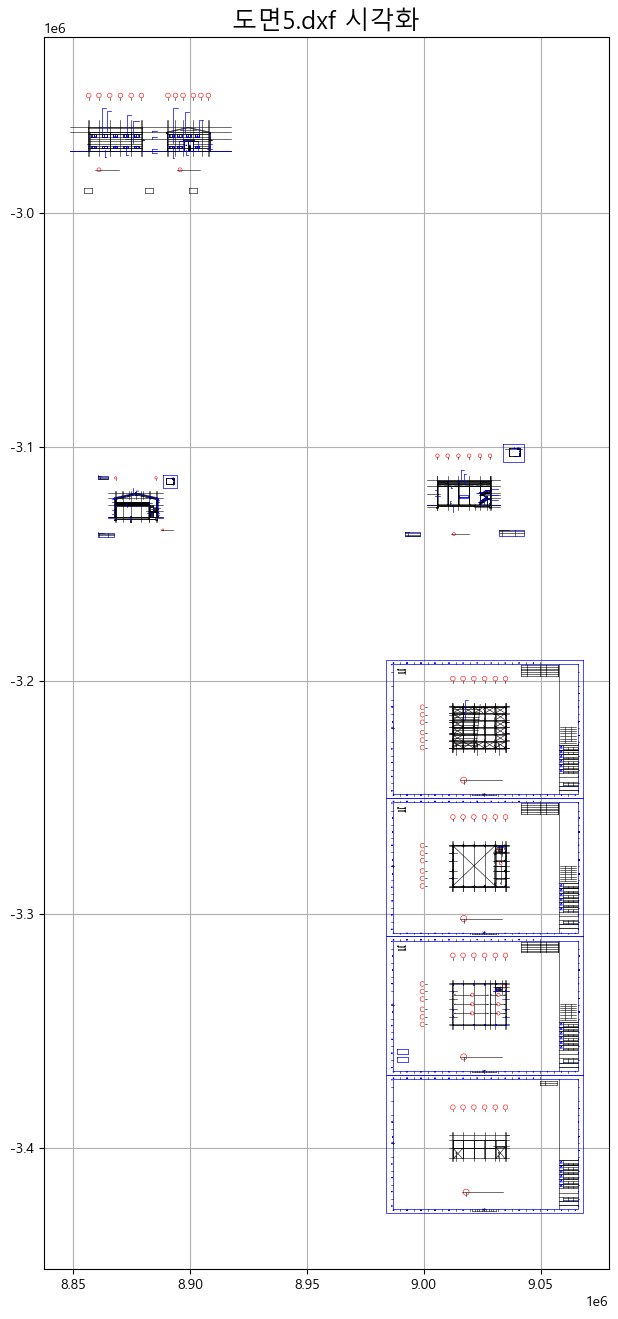

In [4]:
# ============================================================
# [STEP 1] DXF 도면5 시각화 (한글 지원)
# ============================================================

from pathlib import Path
import ezdxf
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 한글 폰트 설정
# ------------------------------------------------------------

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------------------------------------
# DXF 파일 로드
# ------------------------------------------------------------

dxf_path =Path(r"D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data_01\도면5.dxf")

doc = ezdxf.readfile(dxf_path)
msp = doc.modelspace()

# ------------------------------------------------------------
# 시각화
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 16))

for e in msp:

    etype = e.dxftype()

    # --------------------------------------------------------
    # LINE
    # --------------------------------------------------------

    if etype == "LINE":

        x1, y1, _ = e.dxf.start
        x2, y2, _ = e.dxf.end

        ax.plot(
            [x1, x2],
            [y1, y2],
            linewidth=0.4,
            color="black"
        )

    # --------------------------------------------------------
    # LWPOLYLINE
    # --------------------------------------------------------

    elif etype == "LWPOLYLINE":

        points = [(p[0], p[1]) for p in e.get_points()]

        if len(points) >= 2:

            xs, ys = zip(*points)

            if e.closed:
                xs = xs + (xs[0],)
                ys = ys + (ys[0],)

            ax.plot(
                xs,
                ys,
                linewidth=0.5,
                color="blue"
            )

    # --------------------------------------------------------
    # CIRCLE
    # --------------------------------------------------------

    elif etype == "CIRCLE":

        center = e.dxf.center
        radius = e.dxf.radius

        circle = plt.Circle(
            (center.x, center.y),
            radius,
            fill=False,
            linewidth=0.4,
            color="red"
        )

        ax.add_patch(circle)

# ------------------------------------------------------------
# 화면 설정
# ------------------------------------------------------------

ax.set_aspect("equal")
ax.grid(True)

plt.title("도면5.dxf 시각화", fontsize=18)

plt.show()

### 2. 도면 물량 파악

In [3]:
# !pip install ezdxf pandas openpyxl shapely

from pathlib import Path
import ezdxf
import pandas as pd

folder = Path(r"D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data_01")

rows = []

for dxf_path in folder.glob("*.dxf"):
    doc = ezdxf.readfile(dxf_path)
    msp = doc.modelspace()

    for e in msp:
        rows.append({
            "file": dxf_path.name,
            "type": e.dxftype(),
            "layer": e.dxf.layer if e.dxf.hasattr("layer") else None,
            "handle": e.dxf.handle if e.dxf.hasattr("handle") else None,
        })

df = pd.DataFrame(rows)
df.head()

,file,type,layer,handle
0,도면1.dxf,TEXT,TEXT2,854F0
1,도면1.dxf,TEXT,WALL1,95250
2,도면1.dxf,TEXT,WALL1,97D85
3,도면1.dxf,TEXT,WALL1,A05BD
4,도면1.dxf,TEXT,WALL1,A552C


In [4]:
df.groupby(["file", "type"]).size().reset_index(name="count")

,file,type,count
0,도면1.dxf,ARC,16
1,도면1.dxf,CIRCLE,283
2,도면1.dxf,DIMENSION,763
3,도면1.dxf,HATCH,1
4,도면1.dxf,INSERT,604
5,도면1.dxf,LINE,1776
6,도면1.dxf,LWPOLYLINE,697
7,도면1.dxf,TEXT,1324
8,도면2.dxf,ARC,6
9,도면2.dxf,CIRCLE,21


In [5]:
df.groupby(["file", "layer", "type"]).size().reset_index(name="count").sort_values(["file", "layer"])

,file,layer,type,count
0,도면1.dxf,0,CIRCLE,4
1,도면1.dxf,0,INSERT,152
2,도면1.dxf,0,LINE,13
3,도면1.dxf,2,CIRCLE,52
4,도면1.dxf,2,LINE,8
...,...,...,...,...
375,도면5.dxf,WID,TEXT,91
376,도면5.dxf,WIN,LINE,36
377,도면5.dxf,WIN,LWPOLYLINE,19
378,도면5.dxf,글씨,TEXT,30


In [11]:
from pathlib import Path
import ezdxf
import pandas as pd

dxf_path = Path(r"D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data_01\도면1.dxf")
doc = ezdxf.readfile(dxf_path)
msp = doc.modelspace()

rows = []

for e in msp:
    rows.append({
        "type": e.dxftype(),
        "layer": e.dxf.layer if e.dxf.hasattr("layer") else "NONE"
    })

df = pd.DataFrame(rows)

layer_summary = (
    df.groupby(["layer", "type"])
    .size()
    .reset_index(name="count")
    .sort_values(["count"], ascending=False)
)

print(layer_summary)

      layer        type  count
17      DIM   DIMENSION    751
50      TXT        TEXT    351
31    PAPER        TEXT    336
48    TEXT2        TEXT    294
29    PAPER        LINE    290
..      ...         ...    ...
16  CNTLINE      INSERT      2
40   SNG-T2        TEXT      2
22       HA       HATCH      1
56      WID  LWPOLYLINE      1
72       홈통        LINE      1

[73 rows x 3 columns]


In [13]:
insert_rows = []

for e in msp:
    if e.dxftype() == "INSERT":
        insert_rows.append({
            "block_name": e.dxf.name,
            "layer": e.dxf.layer
        })

insert_df = pd.DataFrame(insert_rows)

summary = (
    insert_df.groupby(["block_name", "layer"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(summary.head(50))

                block_name    layer  count
4                   AZ0202   AZ0202    210
1                   AAC001        0    151
6                   AZ0203   AZ0203     96
3                   AAC001       현황     60
2                   AAC001   AAC001     60
10                    데크방향   보조 지시선     12
8                 M-S-CONN   S-BEAM      6
7                   AZ0203       현황      3
5                   AZ0202       현황      3
9   SW_CENTERMARKSYMBOL_13  CNTLINE      2
0                        4        0      1


In [9]:
from pathlib import Path
import pandas as pd

base_dir = Path(r"D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data_02")

# 실제 경로가 다르면 아래처럼 Desktop 기준으로 바꿔야 합니다.
# base_dir = Path(r"C:\Users\hugctx\Desktop\AIFFEL_AI\LLM\Main_Quest\ACE\data_02")

extensions = [".dwg", ".dwf", ".dwfx", ".dxf"]

rows = []

for path in base_dir.rglob("*"):
    if path.is_file() and path.suffix.lower() in extensions:
        rows.append({
            "year": path.relative_to(base_dir).parts[0] if len(path.relative_to(base_dir).parts) > 0 else None,
            "project": path.relative_to(base_dir).parts[1] if len(path.relative_to(base_dir).parts) > 1 else None,
            "file_name": path.name,
            "extension": path.suffix.lower(),
            "full_path": str(path),
        })

df = pd.DataFrame(rows)

print("전체 파일 수:", len(df))
display(df.head(20))

summary = (
    df.groupby(["year", "extension"])
    .size()
    .reset_index(name="count")
    .sort_values(["year", "extension"])
)

display(summary)

전체 파일 수: 724


,year,project,file_name,extension,full_path
0,2024,도서관 리모델링,12.07 삼척도면(건축).dwg,.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
1,2024,배드민턴장,광전리 123-6번지일대 배드민턴장 신축공사-건축(24.03.04).dwg,.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
2,2024,배드민턴장,광전리 123-6번지일대 배드민턴장 신축공사-구조(24.03.04).dwg,.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
3,2024,외벽 타일보수,"240219 시청사 신관 외벽 타일 보수 설계용역_추가,삭제부분.dwg",.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
4,2024,의료시설_구조,"건축지1층, 창호(24.03.12 수정).dwg",.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
5,2024,의료시설_구조,구조(23.02.28)-건축변경.dwg,.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
6,2024,ㅇㅇ고등학교 신축공사,A-001~004 도면목록표.dwg,.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
7,2024,ㅇㅇ고등학교 신축공사,A-011~ 설계개요.dwg,.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
8,2024,ㅇㅇ고등학교 신축공사,A-012 스페이스프로그램.dwg,.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
9,2024,ㅇㅇ고등학교 신축공사,A-013~ 배치도.dwg,.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...


,year,extension,count
0,2024,.dwg,576
1,2025,.dwg,148


In [11]:
from pathlib import Path
import pandas as pd

# ============================================================
# 기준 폴더
# ============================================================

base_dir = Path(r"D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data_02")

# ============================================================
# 찾을 확장자
# ============================================================

extensions = [
    ".dwg",
    ".dwf",
    ".dwfx",
    ".dxf",
    ".xlsx",
    ".xls",
    ".xlsm",
    ".csv"
]

# ============================================================
# 파일 탐색
# ============================================================

rows = []

for path in base_dir.rglob("*"):

    if path.is_file() and path.suffix.lower() in extensions:

        rel_parts = path.relative_to(base_dir).parts

        rows.append({
            "year": rel_parts[0] if len(rel_parts) > 0 else None,
            "project": rel_parts[1] if len(rel_parts) > 1 else None,
            "file_name": path.name,
            "extension": path.suffix.lower(),
            "full_path": str(path),
        })

# ============================================================
# 데이터프레임 생성
# ============================================================

df = pd.DataFrame(rows)

print("전체 파일 수:", len(df))

display(df.head(20))

# ============================================================
# 연도별 + 확장자별 요약
# ============================================================

summary = (
    df.groupby(["year", "extension"])
    .size()
    .reset_index(name="count")
    .sort_values(["year", "extension"])
)

display(summary)

# ============================================================
# 프로젝트별 + 확장자별 요약
# ============================================================

project_summary = (
    df.groupby(["year", "project", "extension"])
    .size()
    .reset_index(name="count")
    .sort_values(["year", "project", "extension"])
)

display(project_summary)

# ============================================================
# 전체 확장자 요약
# ============================================================

ext_summary = (
    df.groupby("extension")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

display(ext_summary)

# ============================================================
# 엑셀 저장
# ============================================================

output_path = base_dir / "file_inventory_summary.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:

    df.to_excel(writer, index=False, sheet_name="all_files")

    summary.to_excel(writer, index=False, sheet_name="year_summary")

    project_summary.to_excel(writer, index=False, sheet_name="project_summary")

    ext_summary.to_excel(writer, index=False, sheet_name="extension_summary")

print("저장 완료:")
print(output_path)

전체 파일 수: 784


,year,project,file_name,extension,full_path
0,2024,ㅇㅇ고등학교 신축공사,A240517001 캠퍼스 고등학교 신축공사_산출서.XLSX,.xlsx,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
1,2024,ㅇㅇ고등학교 신축공사,A240517003 캠퍼스 고등학교 신축공사.XLSX,.xlsx,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
2,2024,공장,A240308000_여주 매룡동 공장 신축공사.xlsx,.xlsx,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
3,2024,다세대주택,A20240412000_고덕동 259-8 다세대주택 신축공사(구조 산출서).xlsx,.xlsx,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
4,2024,다세대주택,A20240412000_고덕동 259-8 다세대주택 신축공사(산출서).XLSX,.xlsx,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
5,2024,다세대주택,A20240412000_고덕동 259-8 다세대주택 신축공사.xlsx,.xlsx,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
6,2024,도서관 리모델링,12.07 삼척도면(건축).dwg,.dwg,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
7,2024,도서관 리모델링,A241113008 삼척 기적의 도서관 인테리어 공사(내역서).xlsx,.xlsx,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
8,2024,도서관 리모델링,A241113008 삼척 기적의 도서관 인테리어 공사(산출서).XLSX,.xlsx,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...
9,2024,배드민턴장,A20240402003 광전리 123-6번지일대 배드민턴장 신축공사_내역서(기계설비...,.xlsx,D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data...


,year,extension,count
0,2024,.dwg,576
1,2024,.xls,10
2,2024,.xlsx,23
3,2025,.dwg,148
4,2025,.xls,1
5,2025,.xlsx,26


,year,project,extension,count
0,2024,ㅇㅇ고등학교 신축공사,.dwg,113
1,2024,ㅇㅇ고등학교 신축공사,.xlsx,3
2,2024,공장,.dwg,34
3,2024,공장,.xlsx,1
4,2024,다세대주택,.dwg,7
5,2024,다세대주택,.xlsx,3
6,2024,도서관 리모델링,.dwg,1
7,2024,도서관 리모델링,.xlsx,2
8,2024,배드민턴장,.dwg,2
9,2024,배드민턴장,.xlsx,1


,extension,count
0,.dwg,724
2,.xlsx,49
1,.xls,11


저장 완료:
D:\PyProject\AIFFEL_AI\LLM\Main_Quest\ACE\data_02\file_inventory_summary.xlsx
